In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer



In [30]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [31]:
df.fillna({'Age': df['Age'].mean()}, inplace=True)

In [32]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [33]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [34]:
X=df.iloc[:,1:3]
Y=df.iloc[:,0]

In [35]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

## PDF plot

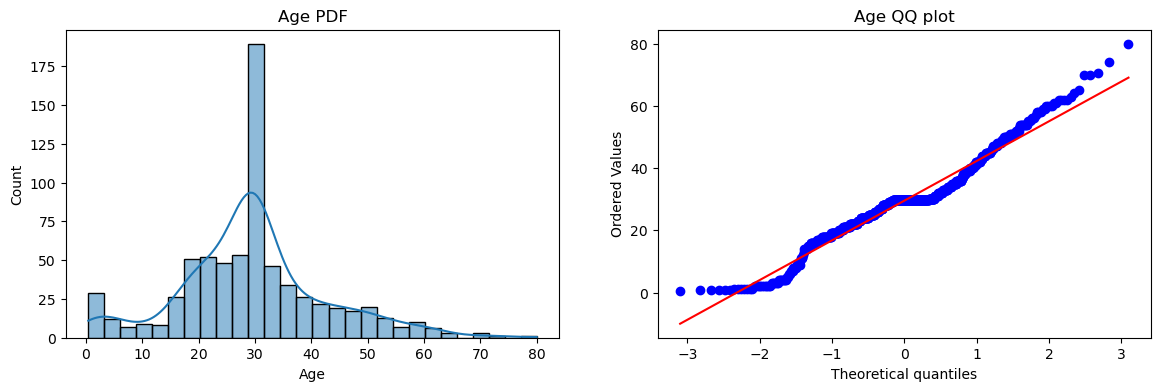

In [36]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ plot')
plt.show()

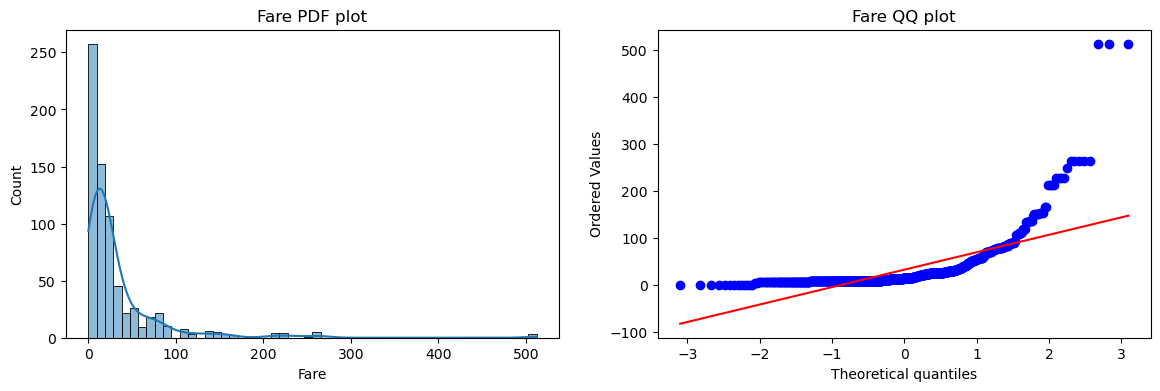

In [37]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'],kde=True)
plt.title('Fare PDF plot')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ plot')
plt.show()

In [38]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [39]:
clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

y_pred=(clf.predict(X_test))
y_pred2=(clf2.predict(X_test))

print('accuracy_LR',accuracy_score(Y_test,y_pred))
print('accuracy_DT',accuracy_score(Y_test,y_pred2))

accuracy_LR 0.6480446927374302
accuracy_DT 0.659217877094972


In [40]:
trf=FunctionTransformer(func=np.log1p)

In [41]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [46]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train_transformed,Y_train)
clf2.fit(X_train_transformed,Y_train)

y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

print('accuracy LR',accuracy_score(Y_test,y_pred))
print('accuracy DT',accuracy_score(Y_test,y_pred2))

accuracy LR 0.6815642458100558
accuracy DT 0.664804469273743
